# Public Wolffia Marker-Panel Review

## tl;dr

This notebook reviews the 60-gene first-pass trusted Wolffia-native marker panel at marker level. It helps decide which genes should remain in the practical scoring panel before the workflow is applied to future control versus salt-stress data.

The notebook produces marker-level summaries, heatmaps, dot plots, and UMAP overlays for representative high-priority genes.

## Context & Methods

The trusted marker panel is smaller than the full gene universe. Its purpose is interpretability: each marker should have a clear reason for inclusion and should behave consistently enough to help interpret Wolffia-native programs.

This notebook uses the structured review table:

`data/metadata/wolffia_trusted_native_marker_panel_review.csv`

It checks:

- marker expression by dawn/dusk group
- marker expression and detection by native cluster
- marker-level behavior for the strongest genes
- whether unknown watchlist genes form coherent expression neighborhoods

### Key assumptions

- The current review calls are first-pass computational calls, not final expert decisions.
- Marker expression is based on normalized/log1p public Waus8730 matrices.
- Large `.h5ad` inputs remain on external project storage.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 2

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name == "notebooks" or not (REPO_ROOT / "data" / "metadata").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

SSD_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")
PROCESSED_DIR = SSD_ROOT / "results" / "processed_h5ad"
MODEL_DIR = SSD_ROOT / "results" / "model_application"

REVIEW_TABLE = REPO_ROOT / "data" / "metadata" / "wolffia_trusted_native_marker_panel_review.csv"
OUT_META = REPO_ROOT / "data" / "metadata"
OUT_FIG = REPO_ROOT / "figures" / "wolffia_marker_panel_review"
OUT_META.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "SRR29417746": {"timepoint": "dawn", "replicate": "dawn_1"},
    "SRR29417745": {"timepoint": "dawn", "replicate": "dawn_2"},
    "SRR29417744": {"timepoint": "dusk", "replicate": "dusk_1"},
    "SRR29417743": {"timepoint": "dusk", "replicate": "dusk_2"},
}
RUNS = list(RUN_METADATA)
print("Repository:", REPO_ROOT)
print("Review table:", REVIEW_TABLE)

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
Review table: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_native_marker_panel_review.csv


## Load review table and public Wolffia cells

In [2]:
review = pd.read_csv(REVIEW_TABLE)
review["marker_label"] = review.apply(
    lambda r: f"{r['preferred_name']}|{r['waus8730_gene_id']}" if r["preferred_name"] != "-" else r["waus8730_gene_id"],
    axis=1,
)
print("Review rows:", len(review))
review.groupby(["native_program_name", "initial_review_call"]).size().unstack(fill_value=0)

Review rows: 60


initial_review_call,keep_initial,supporting_review,unknown_watchlist
native_program_name,,,
Carbon fixation / assimilation,8,0,0
Chloroplast gene expression / plastid translation,6,2,0
Ion / water balance,4,3,0
Lipid / surface / cell-wall biology,7,1,0
Nutrient transport,3,2,0
Photosynthesis / light harvesting,8,0,0
RNA-binding / regulatory,3,0,0
Stress / chaperone response,7,1,0
Unknown high-ranking marker,0,0,5


In [3]:
adatas = []
for run in RUNS:
    h5ad_path = PROCESSED_DIR / f"{run}_normalized_log1p.h5ad"
    pred_path = MODEL_DIR / run / "combined_leaf_root_predictions.csv"
    sample = ad.read_h5ad(h5ad_path)
    sample.obs_names = [f"{run}_{bc}" for bc in sample.obs_names.astype(str)]
    sample.obs["run"] = run
    sample.obs["timepoint"] = RUN_METADATA[run]["timepoint"]
    sample.obs["replicate"] = RUN_METADATA[run]["replicate"]

    predictions = pd.read_csv(pred_path)
    predictions.index = [f"{run}_{bc}" for bc in predictions["cell_id"].astype(str)]
    sample.obs = sample.obs.join(predictions[["final_label", "final_interpretation_status"]], how="left")
    adatas.append(sample)

combined = ad.concat(adatas, join="inner", merge="same", label="run_from_concat", keys=RUNS)
combined.obs["final_label"] = combined.obs["final_label"].fillna("missing_prediction")
combined.obs["final_interpretation_status"] = combined.obs["final_interpretation_status"].fillna("missing_prediction")

print(combined)
print("Cells:", combined.n_obs)
print("Genes:", combined.n_vars)

AnnData object with n_obs × n_vars = 11084 × 15080
    obs: 'run', 'timepoint', 'replicate', 'final_label', 'final_interpretation_status', 'run_from_concat'
    var: 'feature_type'
Cells: 11084
Genes: 15080


## Build marker-level summary table

For each marker, calculate mean expression and detection fraction by dawn/dusk group and across all cells.

In [4]:
def vector_for_gene(adata, gene):
    X = adata[:, gene].X
    if hasattr(X, "toarray"):
        return np.asarray(X.toarray()).ravel()
    return np.asarray(X).ravel()

summary_rows = []
present_genes = [g for g in review["waus8730_gene_id"] if g in combined.var_names]
for _, row in review.iterrows():
    gene = row["waus8730_gene_id"]
    if gene not in combined.var_names:
        continue
    values = vector_for_gene(combined, gene)
    base = row.to_dict()
    summary_rows.append({
        **base,
        "grouping": "all_cells",
        "group": "all_cells",
        "n_cells": combined.n_obs,
        "mean_expression": float(np.mean(values)),
        "detection_fraction": float(np.mean(values > 0)),
    })
    for group_name, idx in combined.obs.groupby("timepoint", observed=True).indices.items():
        group_values = values[list(idx)]
        summary_rows.append({
            **base,
            "grouping": "timepoint",
            "group": group_name,
            "n_cells": len(group_values),
            "mean_expression": float(np.mean(group_values)),
            "detection_fraction": float(np.mean(group_values > 0)),
        })

marker_review_summary = pd.DataFrame(summary_rows)
summary_path = OUT_META / "wolffia_trusted_marker_panel_review_summary.csv"
marker_review_summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
marker_review_summary.query("grouping == 'all_cells'").head()

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_marker_panel_review_summary.csv


,native_program_id,native_program_name,trusted_panel_tier,initial_review_call,manual_review_priority,waus8730_gene_id,preferred_name,source_leiden_clusters,best_marker_rank,max_marker_score,...,reason_for_inclusion,review_note,manual_decision,manual_decision_notes,marker_label,grouping,group,n_cells,mean_expression,detection_fraction
0,carbon_fixation_assimilation,Carbon fixation / assimilation,core_marker,keep_initial,high,Waus8730.v1.chr9.g148620,RCA,6;8,1,33.4219,...,High-evidence marker with top-five rank in at ...,Strong ranked marker with interpretable annota...,NaN,NaN,RCA|Waus8730.v1.chr9.g148620,all_cells,all_cells,11084,4.195725,0.994767
3,carbon_fixation_assimilation,Carbon fixation / assimilation,core_marker,keep_initial,high,Waus8730.v1.chr13.g040080,-,0;11;12,1,30.9583,...,High-evidence marker with top-five rank in at ...,Strong ranked marker with interpretable annota...,NaN,NaN,Waus8730.v1.chr13.g040080,all_cells,all_cells,11084,1.658779,0.690364
6,carbon_fixation_assimilation,Carbon fixation / assimilation,core_marker,keep_initial,high,Waus8730.v1.chr11.g023520,-,0;4;11,3,39.6595,...,High-evidence marker with top-five rank in at ...,Strong ranked marker with interpretable annota...,NaN,NaN,Waus8730.v1.chr11.g023520,all_cells,all_cells,11084,4.162280,0.996391
9,carbon_fixation_assimilation,Carbon fixation / assimilation,core_marker,keep_initial,high,Waus8730.v1.chr20.g087750,-,9,3,36.4510,...,High-evidence marker with top-five rank in at ...,Strong ranked marker with interpretable annota...,NaN,NaN,Waus8730.v1.chr20.g087750,all_cells,all_cells,11084,0.496563,0.229249
12,carbon_fixation_assimilation,Carbon fixation / assimilation,core_marker,keep_initial,high,Waus8730.v1.chr14.g043590,-,6;8,3,28.9053,...,High-evidence marker with top-five rank in at ...,Strong ranked marker with interpretable annota...,NaN,NaN,Waus8730.v1.chr14.g043590,all_cells,all_cells,11084,4.151983,0.991700


## Compute native UMAP and Leiden clusters

This UMAP is used to check whether marker expression localizes to coherent cell neighborhoods.

In [5]:
sc.pp.highly_variable_genes(combined, n_top_genes=3000, flavor="seurat")
sc.pp.pca(combined, n_comps=40, use_highly_variable=True, svd_solver="arpack")
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined, random_state=13)
sc.tl.leiden(combined, resolution=0.8, key_added="leiden_marker_review", random_state=13)
print("Leiden clusters:", combined.obs["leiden_marker_review"].nunique())

extracting highly variable genes


    finished (0:00:00)


computing PCA


    with n_comps=40


    finished (0:00:01)


...

computing UMAP


    finished (0:00:04)


running Leiden clustering


    finished (0:00:01)


Leiden clusters: 15


## Marker heatmap by dawn/dusk group

This heatmap shows the strongest high-priority markers from each program.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_marker_panel_review/trusted_marker_expression_dawn_dusk_heatmap.png


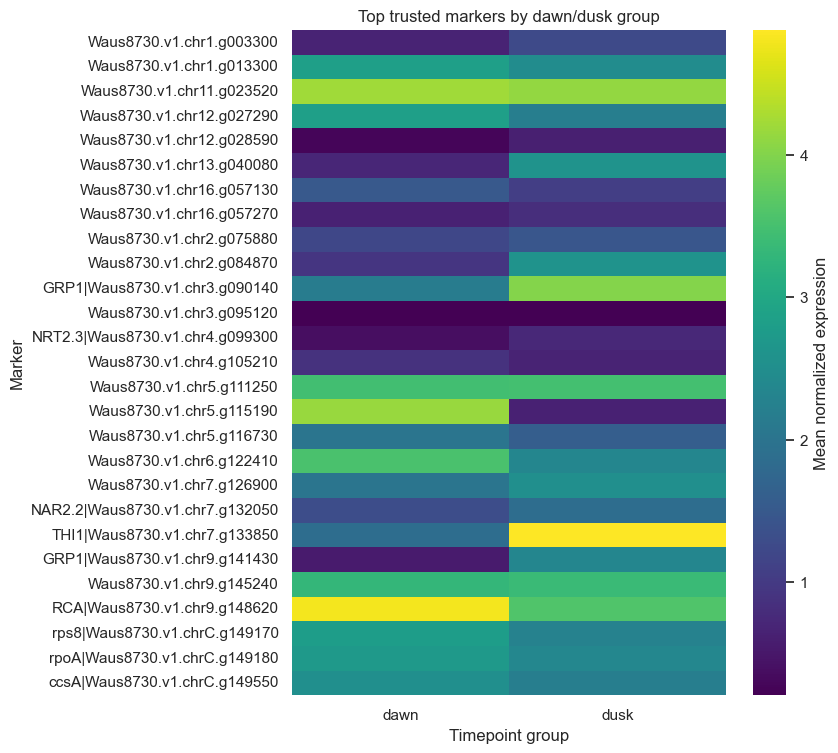

In [6]:
# Select up to three high-priority markers per named program, plus unknown watchlist markers.
plot_markers = []
for program, sub in review.sort_values(["manual_review_priority", "best_marker_rank", "max_marker_score"], ascending=[True, True, False]).groupby("native_program_name", sort=False):
    take = sub.head(3)
    plot_markers.extend(take["waus8730_gene_id"].tolist())
plot_markers = [g for g in dict.fromkeys(plot_markers) if g in combined.var_names]

timepoint_means = []
for gene in plot_markers:
    values = vector_for_gene(combined, gene)
    for tp, idx in combined.obs.groupby("timepoint", observed=True).indices.items():
        timepoint_means.append({"gene": gene, "timepoint": tp, "mean_expression": float(values[list(idx)].mean())})

timepoint_marker_matrix = pd.DataFrame(timepoint_means).pivot(index="gene", columns="timepoint", values="mean_expression")
label_lookup = review.drop_duplicates("waus8730_gene_id").set_index("waus8730_gene_id")["marker_label"].to_dict()
timepoint_marker_matrix.index = [label_lookup.get(g, g) for g in timepoint_marker_matrix.index]

fig, ax = plt.subplots(figsize=(7, max(8, 0.32 * len(timepoint_marker_matrix))))
sns.heatmap(timepoint_marker_matrix, cmap="viridis", ax=ax, cbar_kws={"label": "Mean normalized expression"})
ax.set_title("Top trusted markers by dawn/dusk group")
ax.set_xlabel("Timepoint group")
ax.set_ylabel("Marker")
fig_path = OUT_FIG / "trusted_marker_expression_dawn_dusk_heatmap.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Dot plot by native cluster

The dot plot combines mean marker expression and detection fraction across native Leiden clusters. It is useful for deciding whether a marker is cluster-specific or broadly expressed.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_marker_panel_cluster_summary.csv
Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_marker_panel_review/trusted_marker_cluster_dotplot.png


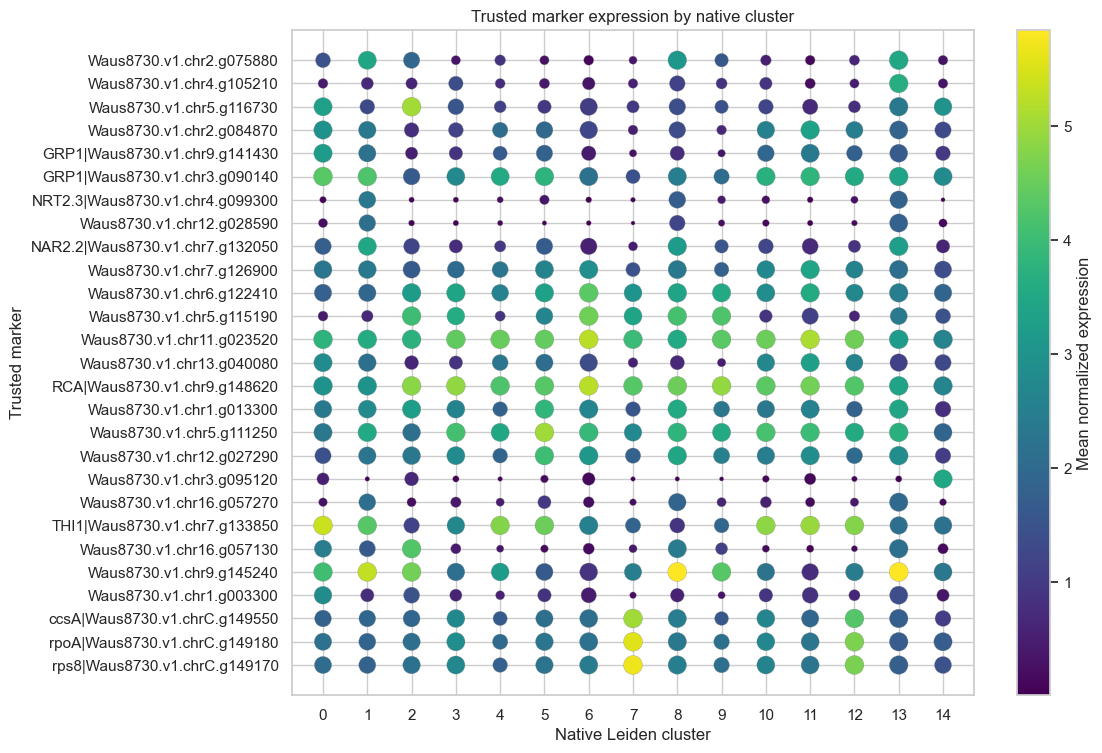

In [7]:
cluster_rows = []
for gene in plot_markers:
    values = vector_for_gene(combined, gene)
    for cluster, idx in combined.obs.groupby("leiden_marker_review", observed=True).indices.items():
        cluster_values = values[list(idx)]
        cluster_rows.append({
            "gene": gene,
            "marker_label": label_lookup.get(gene, gene),
            "cluster": str(cluster),
            "mean_expression": float(cluster_values.mean()),
            "detection_fraction": float((cluster_values > 0).mean()),
        })
cluster_marker_summary = pd.DataFrame(cluster_rows)
cluster_path = OUT_META / "wolffia_trusted_marker_panel_cluster_summary.csv"
cluster_marker_summary.to_csv(cluster_path, index=False)
print("Wrote:", cluster_path)

plot_df = cluster_marker_summary.copy()
plot_df["cluster"] = pd.Categorical(plot_df["cluster"], categories=sorted(plot_df["cluster"].unique(), key=lambda x: int(x)), ordered=True)
fig, ax = plt.subplots(figsize=(11, max(8, 0.32 * plot_df["marker_label"].nunique())))
scatter = ax.scatter(
    plot_df["cluster"].cat.codes,
    plot_df["marker_label"],
    s=plot_df["detection_fraction"] * 180 + 5,
    c=plot_df["mean_expression"],
    cmap="viridis",
    linewidths=0.2,
    edgecolors="grey",
)
ax.set_xticks(range(len(plot_df["cluster"].cat.categories)))
ax.set_xticklabels(plot_df["cluster"].cat.categories)
ax.set_xlabel("Native Leiden cluster")
ax.set_ylabel("Trusted marker")
ax.set_title("Trusted marker expression by native cluster")
fig.colorbar(scatter, ax=ax, label="Mean normalized expression")
fig_path = OUT_FIG / "trusted_marker_cluster_dotplot.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## UMAP overlays for representative markers

These plots show representative high-priority markers from the main candidate programs.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_marker_panel_review/representative_trusted_marker_umap_grid.png


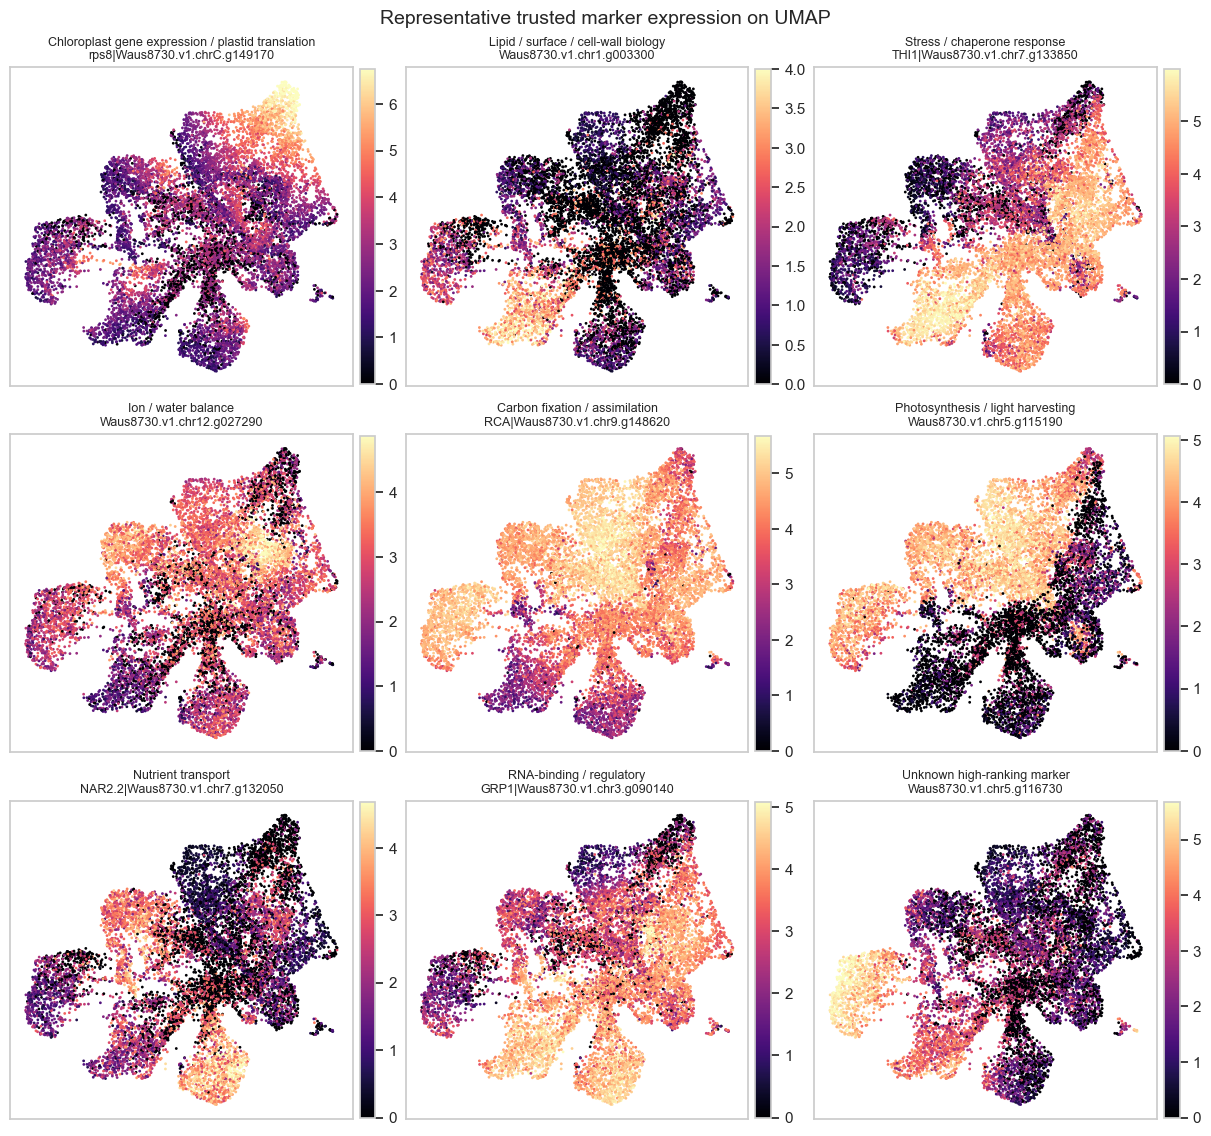

In [8]:
representative_genes = []
for program, sub in review.query("initial_review_call != 'supporting_review'").sort_values(["manual_review_priority", "best_marker_rank", "max_marker_score"], ascending=[True, True, False]).groupby("native_program_name", sort=False):
    gene = sub["waus8730_gene_id"].iloc[0]
    if gene in combined.var_names:
        representative_genes.append(gene)
representative_genes = representative_genes[:9]
coords = combined.obsm["X_umap"]

fig, axes = plt.subplots(3, 3, figsize=(12, 11), constrained_layout=True)
axes = axes.ravel()
for ax, gene in zip(axes, representative_genes):
    values = vector_for_gene(combined, gene)
    vmax = np.percentile(values, 99)
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=4, cmap="magma", vmin=0, vmax=vmax, linewidths=0)
    program = review.loc[review["waus8730_gene_id"] == gene, "native_program_name"].iloc[0]
    label = label_lookup.get(gene, gene)
    ax.set_title(f"{program}\n{label}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.02)
for ax in axes[len(representative_genes):]:
    ax.axis("off")
fig.suptitle("Representative trusted marker expression on UMAP", y=1.02, fontsize=14)
fig_path = OUT_FIG / "representative_trusted_marker_umap_grid.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Review takeaways

The final manual decision columns in `wolffia_trusted_native_marker_panel_review.csv` are intentionally blank. They are where a human reviewer can mark each gene as `keep`, `maybe`, `remove`, or `unknown_interesting` after checking these plots.

In [9]:
print("Cells reviewed:", combined.n_obs)
print("Markers reviewed:", len(review))
print("High-priority rows:", (review["manual_review_priority"] == "high").sum())
print("Medium-priority rows:", (review["manual_review_priority"] == "medium").sum())
print("Unknown watchlist rows:", (review["manual_review_priority"] == "watchlist").sum())
print()
print("Recommended manual-decision vocabulary: keep, maybe, remove, unknown_interesting")

Cells reviewed: 11084
Markers reviewed: 60
High-priority rows: 29
Medium-priority rows: 26
Unknown watchlist rows: 5

Recommended manual-decision vocabulary: keep, maybe, remove, unknown_interesting
